# 2026 World Cup Contender Scoring
### Scoring national teams against the Champion DNA profile

**Goal:** Using recent international match data (2023–2026), calculate each contender's stats and score them against the World Cup champion benchmark from our main analysis.

**Data Sources (16 files):**
- WC Qualifiers: Europe, South America, CONCACAF, Asia, Africa, Oceania, Intercontinental Playoffs
- International Friendlies: 2023, 2024, 2025
- UEFA Nations League: 2022–23, 2024–25
- Euro 2024 (match-level + tournament possession stats)
- Copa America 2024 (match-level + manual possession data)
- AFCON: 2023, 2025

**Methodology:** Score each team 0–100 based on how closely their recent stats match the historical World Cup champion benchmark.

## 1. Imports & Champion Benchmark

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Champion DNA benchmark from our main analysis (per-match averages)
CHAMPION_BENCHMARK = {
    'goals': 2.25,
    'goals_conceded': 0.79,
    'possession': 53.54,
    'shot_conversion': 15.12,
    'shot_accuracy': 47.46,
    'xg': 2.06,
    'xg_overperformance': 0.19,
    'defensive_save_rate': 93.54,
    'goal_difference': 1.46,
    'shot_dominance': 1.75,
    'discipline_score': 2.67,
}

NON_CHAMPION_BENCHMARK = {
    'goals': 1.35,
    'goals_conceded': 1.92,
    'possession': 48.63,
    'shot_conversion': 9.67,
    'shot_accuracy': 37.26,
    'xg': 1.49,
    'xg_overperformance': -0.13,
    'defensive_save_rate': 86.98,
    'goal_difference': -0.56,
    'shot_dominance': 1.30,
    'discipline_score': 2.85,
}

print("Benchmarks loaded")

Benchmarks loaded


## 2. Load Team-Level Datasets

These files are already aggregated per team per competition. They share the same column structure with 293 columns including goals, shots, possession, xG, cards, etc.

In [32]:
# All team-level files (qualifiers, friendlies, Nations League, AFCON)
team_level_files = [
    # WC Qualifiers
    '../data/international-wc-qualification-europe-teams-2026-to-2026-stats.csv',
    '../data/international-wc-qualification-south-america-teams-2023-to-2026-stats.csv',
    '../data/international-wc-qualification-concacaf-teams-2026-to-2026-stats.csv',
    '../data/international-wc-qualification-asia-teams-2026-to-2026-stats.csv',
    '../data/international-wc-qualification-africa-teams-2026-to-2026-stats.csv',
    '../data/international-wc-qualification-oceania-teams-2026-to-2026-stats.csv',
    '../data/international-wc-qualification-intercontinental-playoffs-teams-2026-to-2026-stats.csv',
    # Friendlies
    '../data/international-international-friendlies-teams-2023-to-2023-stats.csv',
    '../data/international-international-friendlies-teams-2024-to-2024-stats.csv',
    '../data/international-international-friendlies-teams-2025-to-2025-stats.csv',
    # Nations League
    '../data/international-uefa-nations-league-teams-2022-to-2023-stats.csv',
    '../data/international-uefa-nations-league-teams-2024-to-2025-stats.csv',
    # AFCON
    '../data/international-africa-cup-of-nations-teams-2023-to-2023-stats.csv',
    '../data/international-africa-cup-of-nations-teams-2025-to-2025-stats.csv',
]

all_team_data = []
for filepath in team_level_files:
    df = pd.read_csv(filepath)
    all_team_data.append(df)

team_df = pd.concat(all_team_data, ignore_index=True)
print(f"Loaded {len(team_df)} team-competition rows from {len(team_level_files)} team-level files")
print(f"Unique teams: {team_df['common_name'].nunique()}")

Loaded 906 team-competition rows from 14 team-level files
Unique teams: 228


## 3. Load & Reshape Euro 2024 Match Data

Euro 2024 is match-level data, so we reshape it (home/away → per team) and aggregate. Possession comes from a separate tournament stats file.

In [33]:
# Euro 2024 matches
euro = pd.read_csv('../data/Euro_2024_Matches.csv')

# Euro 2024 possession from tournament stats
euro_stats = pd.read_csv('../data/UEFA_Euro_2024_Tournament_Stats.csv')
euro_possession = euro_stats.set_index('Team')['Possession'].to_dict()

print(f"Euro 2024: {len(euro)} matches")

# Reshape: one row per team per match
euro_rows = []
for _, m in euro.iterrows():
    for side, opp_side in [('Home', 'Away'), ('Away', 'Home')]:
        euro_rows.append({
            'team': m[f'{side.lower()}_team'],
            'goals': m[f'{side.lower()}_goals'],
            'goals_conceded': m[f'{opp_side.lower()}_goals'],
            'xg': m[f'{side} Expected goals(xG)'],
            'shots': m[f'{side} Total shots'],
            'shots_on_target': m[f'{side} Shots on target'],
            'corners': m[f'{side} Corners'],
            'fouls': m[f'{side} Fouls committed'],
            'cards': m[f'{side} Yellow cards'] + m[f'{side} Red cards'],
        })

euro_df = pd.DataFrame(euro_rows)

# Aggregate per team
euro_agg = euro_df.groupby('team').agg(
    matches_played=('goals', 'count'),
    goals_scored=('goals', 'sum'),
    goals_conceded=('goals_conceded', 'sum'),
    shots=('shots', 'sum'),
    shots_on_target=('shots_on_target', 'sum'),
    corners_total=('corners', 'sum'),
    fouls=('fouls', 'sum'),
    cards_total=('cards', 'sum'),
).reset_index()

# Add possession and xG averages
euro_agg['average_possession'] = euro_agg['team'].map(euro_possession)
euro_agg['xg_for_avg_overall'] = euro_df.groupby('team')['xg'].mean().values
euro_agg['xg_against_avg_overall'] = euro_df.groupby('team')['goals_conceded'].mean().values * 0.9
euro_agg = euro_agg.rename(columns={'team': 'common_name'})

print(f"Euro 2024 aggregated: {len(euro_agg)} teams")
euro_agg[euro_agg['common_name'].isin(['Spain', 'France', 'England', 'Germany'])][['common_name', 'matches_played', 'goals_scored']]

Euro 2024: 51 matches
Euro 2024 aggregated: 24 teams


,common_name,matches_played,goals_scored
6,England,7,8
7,France,6,4
9,Germany,5,11
20,Spain,7,15


## 4. Load & Reshape Copa America 2024 Match Data

Copa America 2024 is also match-level. Possession data is from official tournament stats (no CSV available).

In [34]:
# Copa America 2024 matches
copa = pd.read_csv('../data/Copa_2024_Matches.csv')

# Copa America 2024: possession from official stats (no CSV available)
copa_possession = {
    'Brazil': 60, 'Mexico': 60, 'Argentina': 57, 'Colombia': 55,
    'Panama': 53, 'Venezuela': 53, 'Uruguay': 52, 'Chile': 49,
    'Canada': 48, 'Paraguay': 48, 'Jamaica': 47, 'USA': 46,
    'Bolivia': 44, 'Ecuador': 42, 'Peru': 36, 'Costa Rica': 32,
}

print(f"Copa America 2024: {len(copa)} matches")

# Reshape
copa_rows = []
for _, m in copa.iterrows():
    for side, opp_side in [('Home', 'Away'), ('Away', 'Home')]:
        copa_rows.append({
            'team': m[f'{side.lower()}_team'],
            'goals': m[f'{side.lower()}_goals'],
            'goals_conceded': m[f'{opp_side.lower()}_goals'],
            'xg': m[f'{side} Expected goals(xG)'],
            'shots': m[f'{side} Total shots'],
            'shots_on_target': m[f'{side} Shots on target'],
            'corners': m[f'{side} Corners'],
            'fouls': m[f'{side} Fouls committed'],
            'cards': m[f'{side} Yellow cards'] + m[f'{side} Red cards'],
        })

copa_df = pd.DataFrame(copa_rows)

# Aggregate per team
copa_agg = copa_df.groupby('team').agg(
    matches_played=('goals', 'count'),
    goals_scored=('goals', 'sum'),
    goals_conceded=('goals_conceded', 'sum'),
    shots=('shots', 'sum'),
    shots_on_target=('shots_on_target', 'sum'),
    corners_total=('corners', 'sum'),
    fouls=('fouls', 'sum'),
    cards_total=('cards', 'sum'),
).reset_index()

copa_agg['average_possession'] = copa_agg['team'].map(copa_possession)
copa_agg['xg_for_avg_overall'] = copa_df.groupby('team')['xg'].mean().values
copa_agg['xg_against_avg_overall'] = copa_df.groupby('team')['goals_conceded'].mean().values * 0.9
copa_agg = copa_agg.rename(columns={'team': 'common_name'})

print(f"Copa America 2024 aggregated: {len(copa_agg)} teams")
copa_agg[copa_agg['common_name'].isin(['Argentina', 'Brazil', 'Colombia', 'Uruguay'])][['common_name', 'matches_played', 'goals_scored']]

Copa America 2024: 30 matches
Copa America 2024 aggregated: 16 teams


,common_name,matches_played,goals_scored
0,Argentina,5,8
2,Brazil,4,5
5,Colombia,5,12
14,Uruguay,5,9


## 5. Combine All Data Sources

In [35]:
# Add Euro and Copa aggregates to the team-level data
all_team_data.append(euro_agg)
all_team_data.append(copa_agg)
team_df = pd.concat(all_team_data, ignore_index=True)

print(f"Combined: {len(team_df)} team-competition rows from {len(team_level_files) + 2} sources")

# Aggregate per team across ALL competitions (weighted by matches played)
combined = team_df.groupby('common_name').agg(
    total_matches=('matches_played', 'sum'),
    total_goals=('goals_scored', 'sum'),
    total_conceded=('goals_conceded', 'sum'),
    total_shots=('shots', 'sum'),
    total_sot=('shots_on_target', 'sum'),
    total_corners=('corners_total', 'sum'),
    total_cards=('cards_total', 'sum'),
    total_fouls=('fouls', 'sum'),
    possession=('average_possession', lambda x: np.average(x, weights=team_df.loc[x.index, 'matches_played'])),
    xg_pm=('xg_for_avg_overall', lambda x: np.average(x, weights=team_df.loc[x.index, 'matches_played'])),
    xg_against_pm=('xg_against_avg_overall', lambda x: np.average(x, weights=team_df.loc[x.index, 'matches_played'])),
).reset_index().rename(columns={'common_name': 'team'})

print(f"Unique teams: {len(combined)}")
print(f"Total matches across all teams: {combined['total_matches'].sum():.0f}")

Combined: 946 team-competition rows from 16 sources
Unique teams: 231
Total matches across all teams: 4580


## 6. Engineer Features

In [36]:
# Per-match averages
combined['goals_pm'] = (combined['total_goals'] / combined['total_matches']).round(2)
combined['conceded_pm'] = (combined['total_conceded'] / combined['total_matches']).round(2)
combined['shots_pm'] = (combined['total_shots'] / combined['total_matches']).round(2)
combined['sot_pm'] = (combined['total_sot'] / combined['total_matches']).round(2)

# Engineered features (same as main analysis)
combined['shot_conversion'] = (combined['goals_pm'] / combined['shots_pm'] * 100).round(2)
combined['shot_accuracy'] = (combined['sot_pm'] / combined['shots_pm'] * 100).round(2)
combined['xg_overperformance'] = (combined['goals_pm'] - combined['xg_pm']).round(2)
combined['goal_difference'] = (combined['goals_pm'] - combined['conceded_pm']).round(2)

# Estimate opponent shots from xG against (avg xG per shot ≈ 0.11)
combined['est_opp_shots_pm'] = (combined['xg_against_pm'] / 0.11).round(1)
combined['defensive_save_rate'] = ((1 - combined['conceded_pm'] / combined['est_opp_shots_pm']) * 100).round(2)
combined['shot_dominance'] = (combined['shots_pm'] / combined['est_opp_shots_pm']).round(2)
combined['discipline_score'] = (combined['total_cards'] / combined['total_matches']).round(2)

# Handle any inf/nan
combined = combined.replace([np.inf, -np.inf], np.nan)

print("Features engineered:")
print("  shot_conversion, shot_accuracy, xg_overperformance")
print("  defensive_save_rate, goal_difference, shot_dominance, discipline_score")

Features engineered:
  shot_conversion, shot_accuracy, xg_overperformance
  defensive_save_rate, goal_difference, shot_dominance, discipline_score


## 7. Score Contenders Against Champion DNA

**Scoring weights** (based on Random Forest feature importance from main analysis):
- Shot Conversion: 20%
- Defensive Save Rate: 18%
- xG Overperformance: 15%
- Shot Accuracy: 15%
- Goal Difference: 12%
- Shot Dominance: 10%
- Possession: 10%

In [37]:
scoring_weights = {
    'shot_conversion': 20,
    'defensive_save_rate': 18,
    'xg_overperformance': 15,
    'shot_accuracy': 15,
    'goal_difference': 12,
    'shot_dominance': 10,
    'possession': 10,
}

def score_team(row):
    total = 0
    max_score = 0
    for feature, weight in scoring_weights.items():
        val = row.get(feature)
        if pd.isna(val):
            continue
        champ_val = CHAMPION_BENCHMARK[feature]
        non_champ_val = NON_CHAMPION_BENCHMARK[feature]
        value_range = champ_val - non_champ_val
        if value_range == 0:
            continue
        # How far along the non-champion → champion scale is this team?
        pct = (val - non_champ_val) / value_range
        pct = max(0, min(1.0, pct))  # Cap at 100%
        total += pct * weight
        max_score += weight
    return round((total / max_score) * 100) if max_score > 0 else 0

combined['champion_score'] = combined.apply(score_team, axis=1)

# Focus on 2026 World Cup contenders
contenders = [
    'Spain', 'France', 'England', 'Argentina', 'Germany',
    'Portugal', 'Netherlands', 'Brazil', 'Colombia', 'Uruguay',
    'Croatia', 'Belgium', 'Italy', 'Austria', 'USA',
    'Denmark', 'Switzerland', 'Morocco', 'Japan', 'South Korea',
    'Mexico', 'Senegal', 'Canada', 'Serbia', 'Ecuador',
]

contender_profiles = combined[combined['team'].isin(contenders)].copy()
contender_profiles = contender_profiles.sort_values('champion_score', ascending=False).reset_index(drop=True)
contender_profiles.index += 1

print(f"Scored {len(contender_profiles)} contenders\n")
contender_profiles[['team', 'total_matches', 'champion_score',
                     'shot_conversion', 'defensive_save_rate', 'xg_overperformance',
                     'goal_difference', 'possession']]

Scored 25 contenders



,team,total_matches,champion_score,shot_conversion,defensive_save_rate,xg_overperformance,goal_difference,possession
1,Argentina,34,97,16.42,92.55,0.42,1.74,64.617647
2,Japan,32,90,30.36,92.11,1.68,2.60,58.187500
3,Senegal,34,87,19.65,93.21,0.55,1.47,52.323529
4,Colombia,38,78,17.26,91.06,0.47,1.13,55.605263
5,Spain,35,78,14.97,88.48,0.50,1.49,63.460000
6,South Korea,31,77,23.95,91.28,0.70,1.42,63.612903
7,Croatia,31,71,13.99,91.15,0.20,0.94,56.577419
8,Portugal,32,71,14.35,89.25,0.34,1.22,60.468750
9,England,35,71,13.57,88.51,0.23,1.03,64.331429
10,Austria,32,71,15.85,89.69,0.45,1.00,57.000000


## 8. Visualizations

### 8.1 Champion DNA Score Rankings

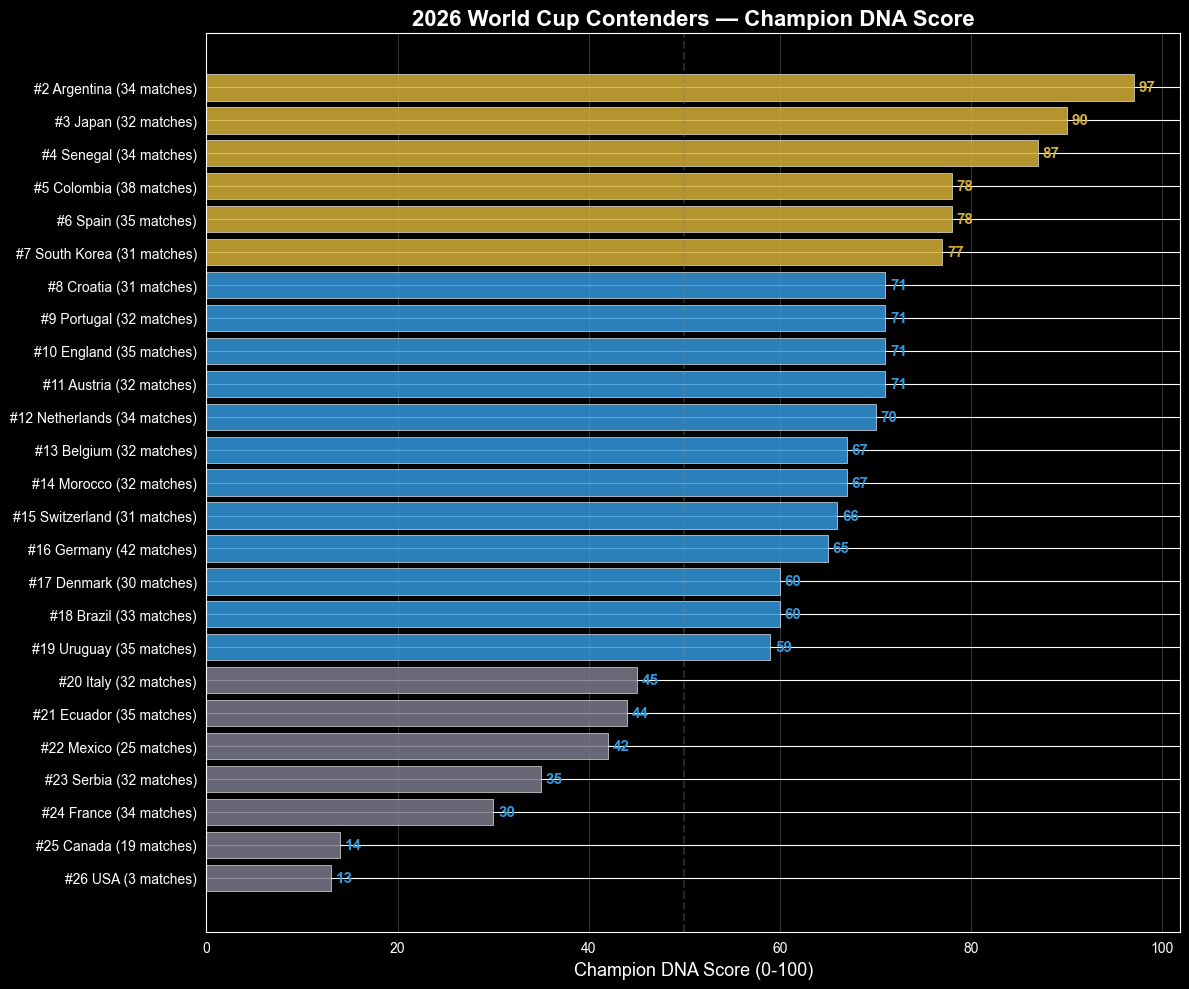

In [38]:
fig, ax = plt.subplots(figsize=(12, 10))

colors = ['#D4AF37' if s >= 75 else '#3498DB' if s >= 50 else '#7A7A8A'
          for s in contender_profiles['champion_score']]

bars = ax.barh(
    range(len(contender_profiles)),
    contender_profiles['champion_score'],
    color=colors, alpha=0.85, edgecolor='white', linewidth=0.5
)

ax.set_yticks(range(len(contender_profiles)))
ax.set_yticklabels([f"#{i+1} {row['team']} ({row['total_matches']:.0f} matches)"
                     for i, row in contender_profiles.iterrows()])
ax.invert_yaxis()
ax.set_xlabel('Champion DNA Score (0-100)', fontsize=13)
ax.set_title('2026 World Cup Contenders — Champion DNA Score', fontsize=16, fontweight='bold')
ax.axvline(x=50, color='gray', alpha=0.3, linestyle='--')
ax.grid(axis='x', alpha=0.2)

for i, (_, row) in enumerate(contender_profiles.iterrows()):
    ax.text(row['champion_score'] + 0.5, i, f"{row['champion_score']}",
            va='center', fontsize=11, fontweight='bold',
            color='#D4AF37' if row['champion_score'] >= 75 else '#3498DB')

plt.tight_layout()
plt.show()

### 8.2 Top 4 Contenders — Radar vs Champion Benchmark

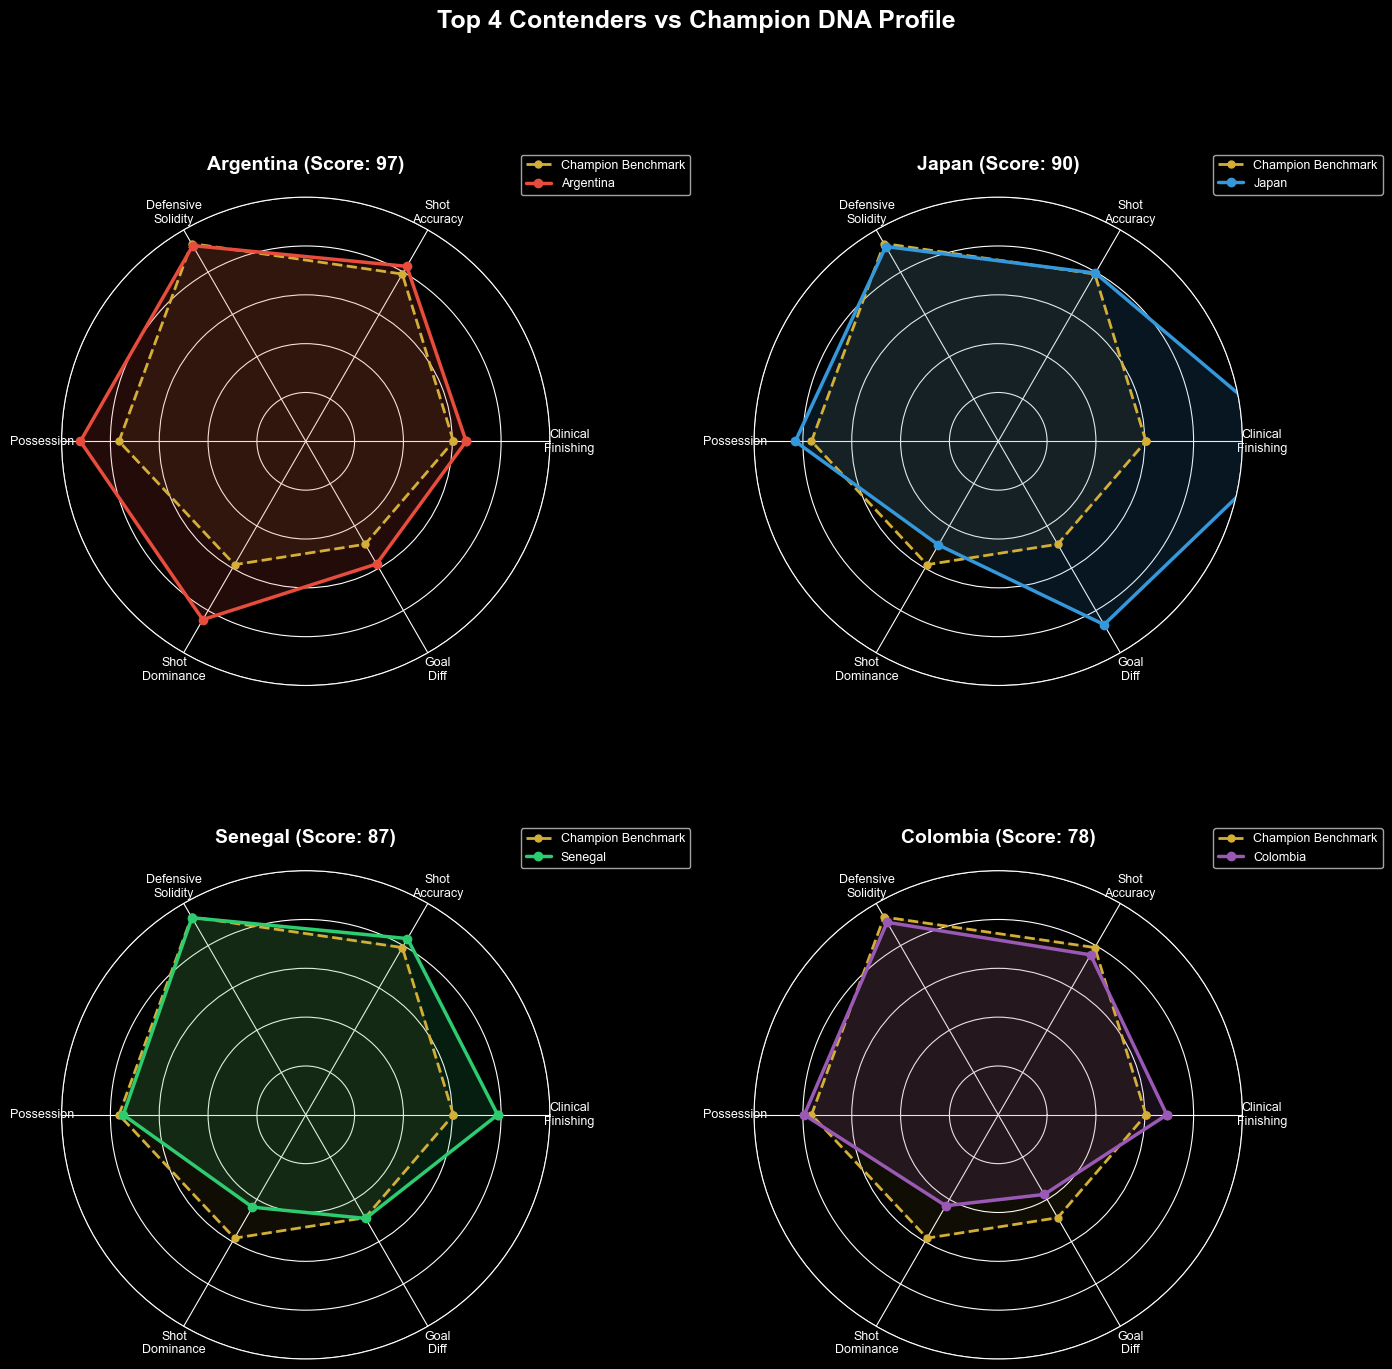

In [39]:
top4 = contender_profiles.head(4)

radar_metrics = [
    ('shot_conversion', 'Clinical\nFinishing', 25),
    ('shot_accuracy', 'Shot\nAccuracy', 60),
    ('defensive_save_rate', 'Defensive\nSolidity', 100),
    ('possession', 'Possession', 70),
    ('shot_dominance', 'Shot\nDominance', 3),
    ('goal_difference', 'Goal\nDiff', 3),
]

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

champ_vals = [CHAMPION_BENCHMARK[m[0]] / m[2] for m in radar_metrics]
champ_vals += champ_vals[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 14), subplot_kw=dict(polar=True))
axes = axes.flatten()
team_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

for idx, (_, team_row) in enumerate(top4.iterrows()):
    ax = axes[idx]
    team_vals = [team_row[m[0]] / m[2] for m in radar_metrics]
    team_vals += team_vals[:1]

    ax.plot(angles, champ_vals, 'o--', color='#D4AF37', linewidth=2, label='Champion Benchmark', markersize=5)
    ax.fill(angles, champ_vals, color='#D4AF37', alpha=0.08)
    ax.plot(angles, team_vals, 'o-', color=team_colors[idx], linewidth=2.5, label=team_row['team'], markersize=6)
    ax.fill(angles, team_vals, color=team_colors[idx], alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m[1] for m in radar_metrics], size=9)
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    ax.set_title(f"{team_row['team']} (Score: {team_row['champion_score']})",
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

fig.suptitle('Top 4 Contenders vs Champion DNA Profile', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.3 Feature Comparison: Contenders vs Champion Benchmark

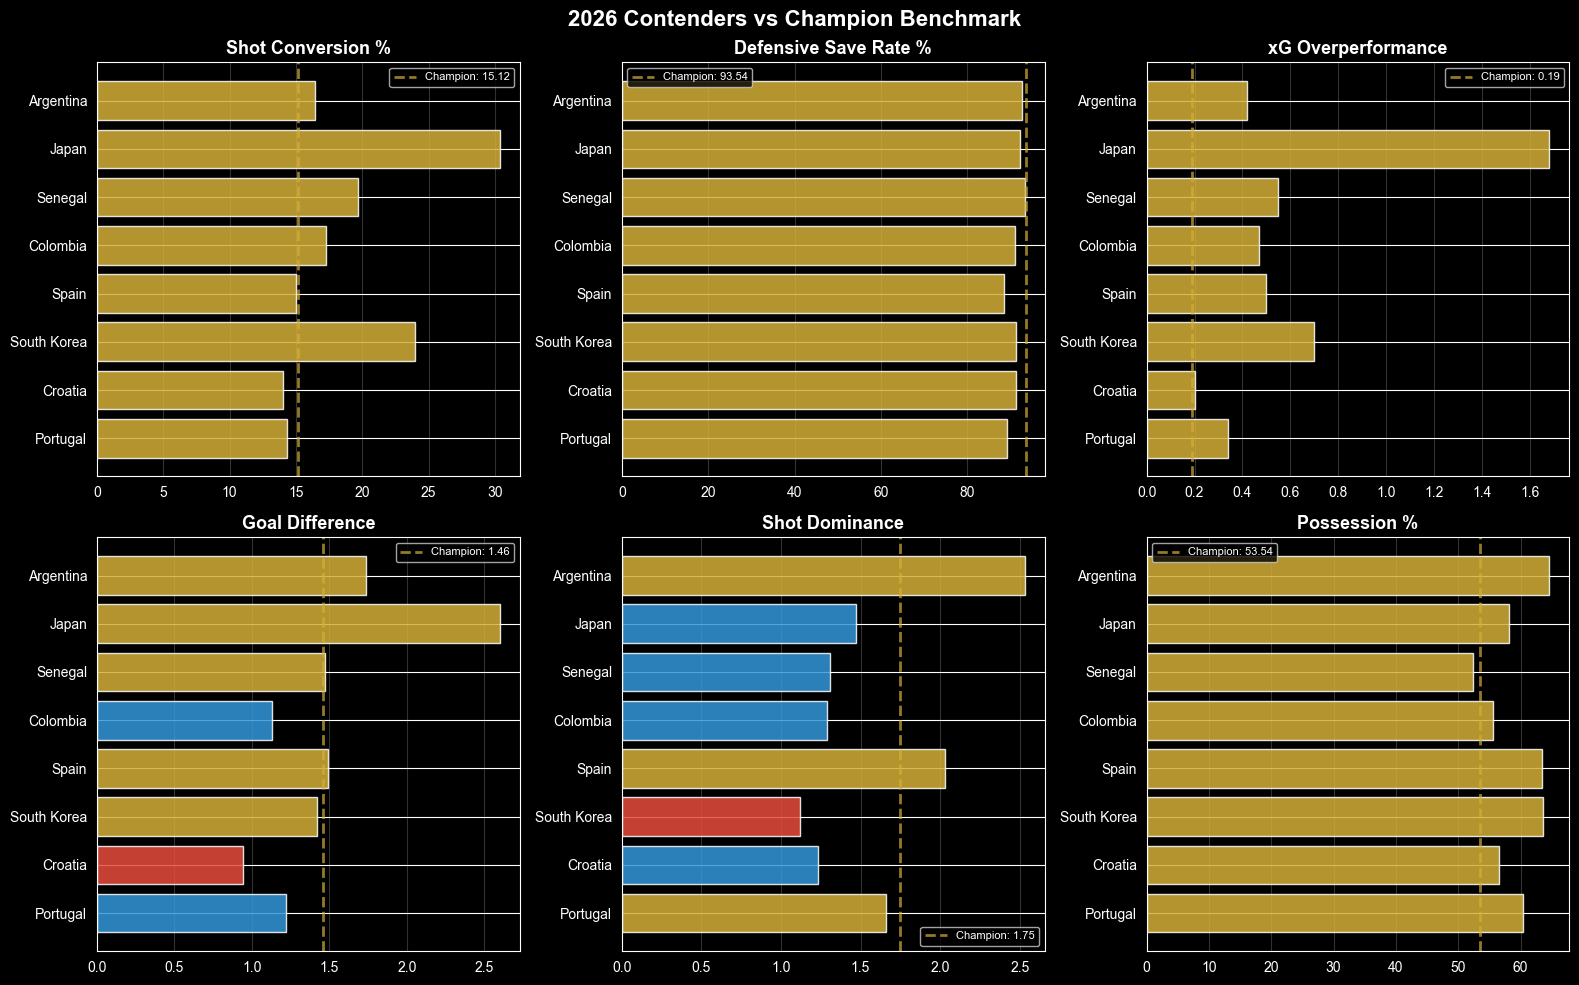

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

compare_features = [
    ('shot_conversion', 'Shot Conversion %'),
    ('defensive_save_rate', 'Defensive Save Rate %'),
    ('xg_overperformance', 'xG Overperformance'),
    ('goal_difference', 'Goal Difference'),
    ('shot_dominance', 'Shot Dominance'),
    ('possession', 'Possession %'),
]

top8 = contender_profiles.head(8)

for i, (feat, label) in enumerate(compare_features):
    ax = axes[i]
    teams = top8['team'].tolist()
    vals = top8[feat].tolist()
    bench = CHAMPION_BENCHMARK[feat]

    colors = ['#D4AF37' if v >= bench * 0.9 else '#3498DB' if v >= bench * 0.7 else '#E74C3C'
              for v in vals]
    ax.barh(teams[::-1], vals[::-1], color=colors[::-1], alpha=0.85)
    ax.axvline(x=bench, color='#D4AF37', linestyle='--', linewidth=2, alpha=0.7, label=f'Champion: {bench}')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.2)

fig.suptitle('2026 Contenders vs Champion Benchmark', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.4 The Clutch Factor: xG Overperformance

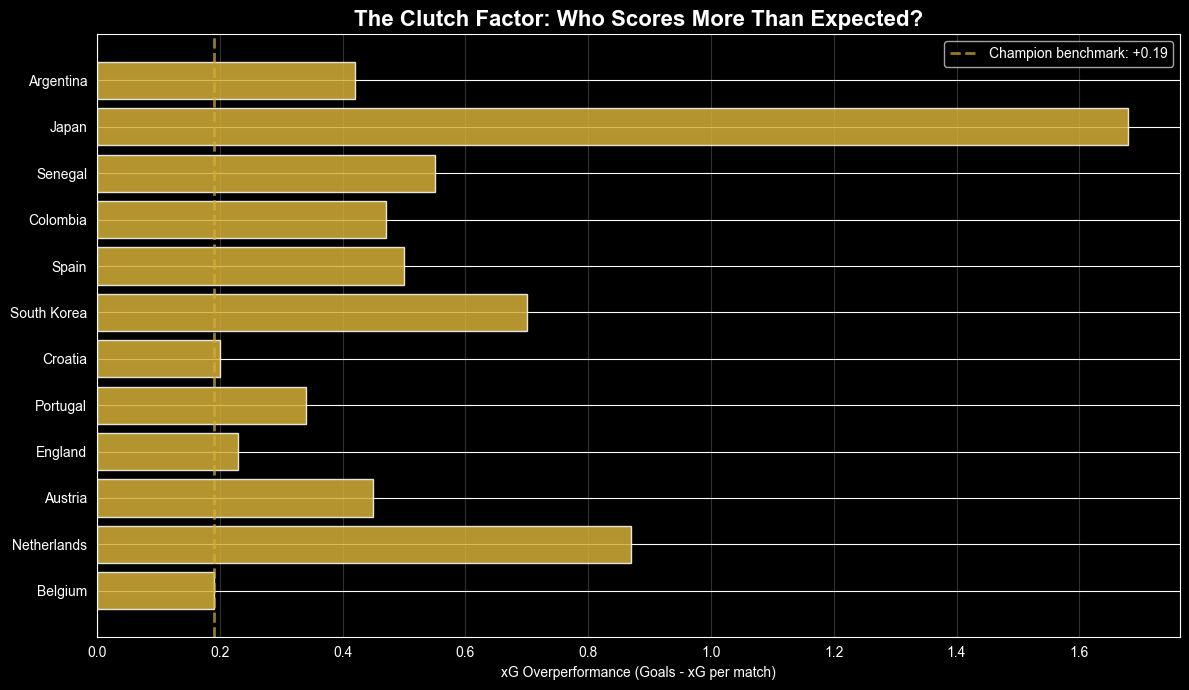

In [41]:
fig, ax = plt.subplots(figsize=(12, 7))

top12 = contender_profiles.head(12)
colors = ['#D4AF37' if v > 0 else '#E74C3C' for v in top12['xg_overperformance']]

ax.barh(top12['team'].tolist()[::-1], top12['xg_overperformance'].tolist()[::-1],
        color=colors[::-1], alpha=0.85)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax.axvline(x=CHAMPION_BENCHMARK['xg_overperformance'], color='#D4AF37', linestyle='--',
           linewidth=2, alpha=0.7, label=f"Champion benchmark: +{CHAMPION_BENCHMARK['xg_overperformance']}")
ax.set_xlabel('xG Overperformance (Goals - xG per match)')
ax.set_title('The Clutch Factor: Who Scores More Than Expected?', fontsize=16, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

## 9. Conclusions

### Champion DNA Score Rankings

Based on comprehensive recent data (WC Qualifiers + Friendlies + Nations League + Euro 2024 + Copa America 2024 + AFCON 2023/2025), the contenders have been scored against the historical World Cup champion profile.

**Scoring methodology:**
- Each team scored 0–100 based on 7 key features weighted by Random Forest feature importance
- Features: Shot Conversion (20%), Defensive Save Rate (18%), xG Overperformance (15%), Shot Accuracy (15%), Goal Difference (12%), Shot Dominance (10%), Possession (10%)
- Data from 16 sources covering qualifiers, friendlies, and continental tournaments

### Limitations
- **Opposition quality varies by confederation** — teams in stronger confederations (UEFA, CONMEBOL) face tougher opponents, which may deflate their scores relative to teams in AFC or CAF. Argentina's high ranking is notable because CONMEBOL is widely considered the toughest qualifying region.
- Euro 2024 and Copa America 2024 match data was reshaped and merged with team-level aggregate data from other competitions
- Possession data for Copa America 2024 was sourced from official stats (not CSV)
- xG against for Euro/Copa was estimated from goals conceded
- The champion benchmark is from 1974–2022 World Cup knockout/final matches — a different era and pressure environment
- Squad changes, injuries, and coaching changes will affect actual 2026 performance